In [14]:
import pandas as pd

In [15]:
# Get demand
demand_df = pd.read_csv('cebu_demand.csv', index_col=0).reset_index()
demand_df = demand_df.groupby('Program', as_index=False).agg({
    'Sector': 'first',                # just keep the sector (passes through)
    'Worst Demand': 'sum',
    'Base Demand': 'sum',     # sum the demand
    'Best Demand': 'sum'              # sum the demand
})
demand_df['Program'] = demand_df['Program'].replace({
    'FOOD PRODUCTION (BREAD AND PATISSERIE) NC II': 'BREAD AND PASTRY PRODUCTION NC II'
})
demand_df['Sector'].replace({'TOURISM (HOTEL AND RESTAURANT)':'HOSPITALITY'}, inplace=True)

# Get supply
supply_df = pd.read_csv('cebu_supply.csv', index_col=0).reset_index()
supply_df = supply_df.groupby('Qualification')['Graduates'].sum().reset_index()
supply_df['Qualification'] = supply_df['Qualification'].str.upper()

# Merge them both thru an outer join
cebu_market_df = pd.merge(
    supply_df,                # left side = all qualifications
    demand_df,                # right side = matching demand
    left_on='Qualification',
    right_on='Program',
    how='left'                # only bring in demand if it exists
)

ordered_columns = ['Qualification', 'Sector', 'Worst Demand', 'Base Demand', 'Best Demand', 'Graduates']
cebu_market_df = cebu_market_df[ordered_columns].dropna()

In [11]:
ordered_columns = ['Qualification', 'Sector', 'Worst_Expected_Total',  'Base_Expected_Total', 'Best_Expected_Total', 'Graduates']
bohol_market_df = pd.read_csv('bohol_supply_gap_final.csv')[ordered_columns]
bohol_market_df.rename(columns={'Worst_Expected_Total':'Worse Demand', 
                                'Base_Expected_Total':'Base Demand',
                                'Best_Expected_Total':'Best Demand'}, inplace=True)

In [5]:
region_vii_market_df = pd.concat([cebu_market_df, bohol_market_df])

In [6]:
region_vii_market_df.groupby('Sector')[['Worst Demand', 'Base Demand', 'Best Demand', 'Graduates']].sum()

,Worst Demand,Base Demand,Best Demand,Graduates
Sector,,,,
CONSTRUCTION,5960.0,11805.0,55810.0,3553.0
HOSPITALITY,2880.0,5135.0,10270.0,4461.0
MANUFACTURING,2836.0,5045.0,11770.0,9135.0


In [7]:
qualification_df = region_vii_market_df.groupby('Qualification').agg({
    'Sector':'first',
    'Worst Demand': 'sum',
    'Base Demand':'sum',
    'Best Demand':'sum',
    'Graduates':'sum'
})
qualification_df['Worst Supply Gap'] = qualification_df['Worst Demand'] - qualification_df['Graduates']
qualification_df['Base Supply Gap'] = qualification_df['Base Demand'] - qualification_df['Graduates']
qualification_df['Best Supply Gap'] = qualification_df['Best Demand'] - qualification_df['Graduates']

In [13]:
qualification_df

,Sector,Worst Demand,Base Demand,Best Demand,Graduates,Worst Supply Gap,Base Supply Gap,Best Supply Gap
Qualification,,,,,,,,
BARISTA NC II,HOSPITALITY,300.0,500.0,1000.0,79.0,221.0,421.0,921.0
BARTENDING NC II,HOSPITALITY,300.0,545.0,1090.0,116.0,184.0,429.0,974.0
BREAD AND PASTRY PRODUCTION NC II,MANUFACTURING,546.0,955.0,2190.0,5898.0,-5352.0,-4943.0,-3708.0
CARPENTRY NC II,CONSTRUCTION,1740.0,2970.0,5940.0,168.0,1572.0,2802.0,5772.0
CONSTRUCTION PAINTING NC II,CONSTRUCTION,879.0,1405.0,11630.0,16.0,863.0,1389.0,11614.0
COOKERY NC II,MANUFACTURING,900.0,1620.0,3240.0,2870.0,-1970.0,-1250.0,370.0
ELECTRICAL INSTALLATION AND MAINTENANCE NC II,CONSTRUCTION,780.0,1560.0,3120.0,1536.0,-756.0,24.0,1584.0
ELECTRICAL INSTALLATION AND MAINTENANCE NC III,CONSTRUCTION,438.0,850.0,5340.0,132.0,306.0,718.0,5208.0
ELECTRICAL INSTALLATION AND MAINTENANCE NC IV,CONSTRUCTION,0.0,105.0,210.0,0.0,0.0,105.0,210.0


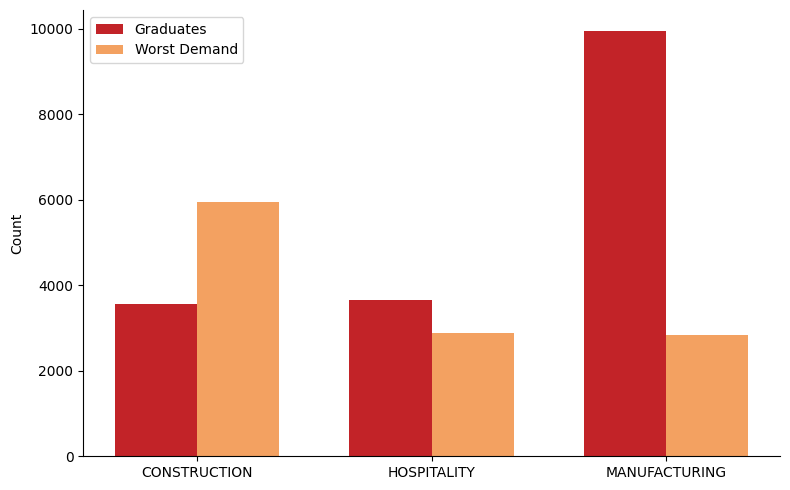

In [12]:
import matplotlib.pyplot as plt 
plot_df = qualification_df.dropna(subset=['Sector'])

# Group by sector and sum the relevant columns
sector_summary = plot_df.groupby('Sector')[['Worst Demand', 'Graduates']].sum().reset_index()

# --- Plot ---
x = range(len(sector_summary))
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(8, 5))

# Bars for Graduates
ax.bar([i - width/2 for i in x], sector_summary['Graduates'], width, label='Graduates', color='#C22328')

# Bars for Base Demand
ax.bar([i + width/2 for i in x], sector_summary['Worst Demand'], width, label='Worst Demand', color='#f3a161')

# Formatting
ax.set_xlabel('')
ax.set_ylabel('Count')
#ax.set_title('Base Demand vs Graduates per Sector')
ax.set_xticks(x)
ax.set_xticklabels(sector_summary['Sector'])
ax.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


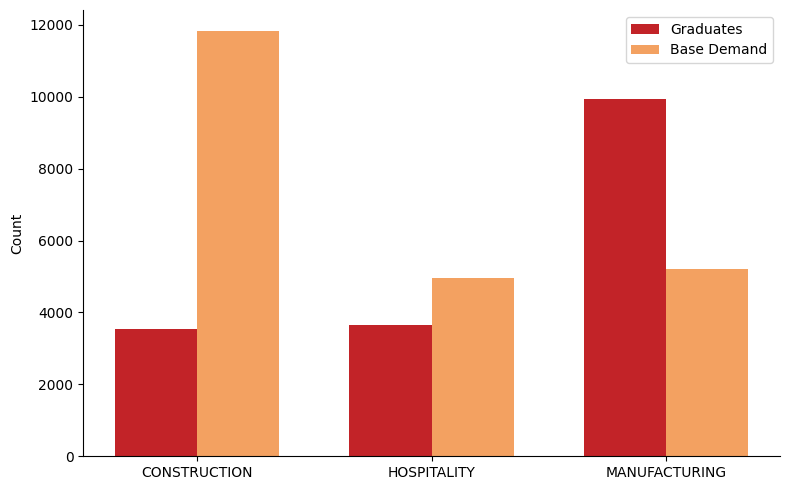

In [9]:
import matplotlib.pyplot as plt 
plot_df = qualification_df.dropna(subset=['Sector'])

# Group by sector and sum the relevant columns
sector_summary = plot_df.groupby('Sector')[['Base Demand', 'Graduates']].sum().reset_index()

# --- Plot ---
x = range(len(sector_summary))
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(8, 5))

# Bars for Graduates
ax.bar([i - width/2 for i in x], sector_summary['Graduates'], width, label='Graduates', color='#C22328')

# Bars for Base Demand
ax.bar([i + width/2 for i in x], sector_summary['Base Demand'], width, label='Base Demand', color='#f3a161')

# Formatting
ax.set_xlabel('')
ax.set_ylabel('Count')
#ax.set_title('Base Demand vs Graduates per Sector')
ax.set_xticks(x)
ax.set_xticklabels(sector_summary['Sector'])
ax.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


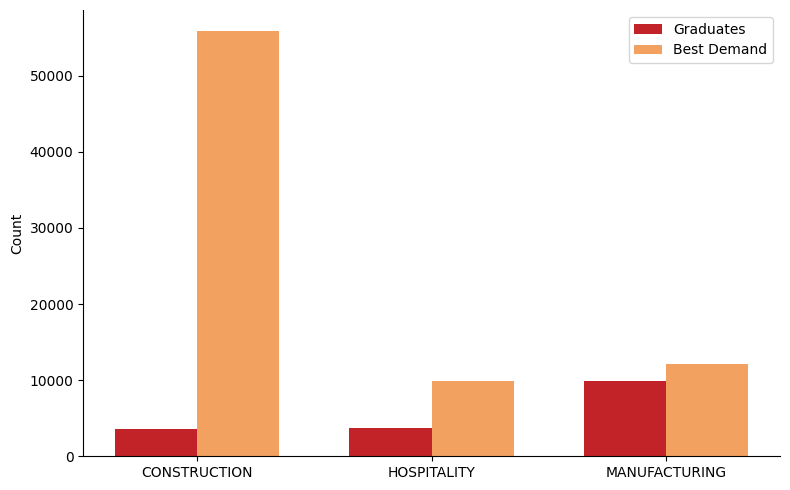

In [10]:
plot_df = qualification_df.dropna(subset=['Sector'])

# Group by sector and sum the relevant columns
sector_summary = plot_df.groupby('Sector')[['Best Demand', 'Graduates']].sum().reset_index()

# --- Plot ---
x = range(len(sector_summary))
width = 0.35  # width of each bar

fig, ax = plt.subplots(figsize=(8, 5))

# Bars for Graduates
ax.bar([i - width/2 for i in x], sector_summary['Graduates'], width, label='Graduates', color='#C22328')

# Bars for Base Demand
ax.bar([i + width/2 for i in x], sector_summary['Best Demand'], width, label='Best Demand', color='#f3a161')

# Formatting
ax.set_xlabel('')
ax.set_ylabel('Count')
#ax.set_title('Best Demand vs Graduates per Sector')
ax.set_xticks(x)
ax.set_xticklabels(sector_summary['Sector'], rotation=0)
ax.legend()

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


In [11]:
scenario_demand = 'Worst Demand'
(bottom[scenario_demand].sum() + middle[scenario_demand].sum() + top[scenario_demand].sum())/qualification_df[scenario_demand].sum()

NameError: name 'bottom' is not defined

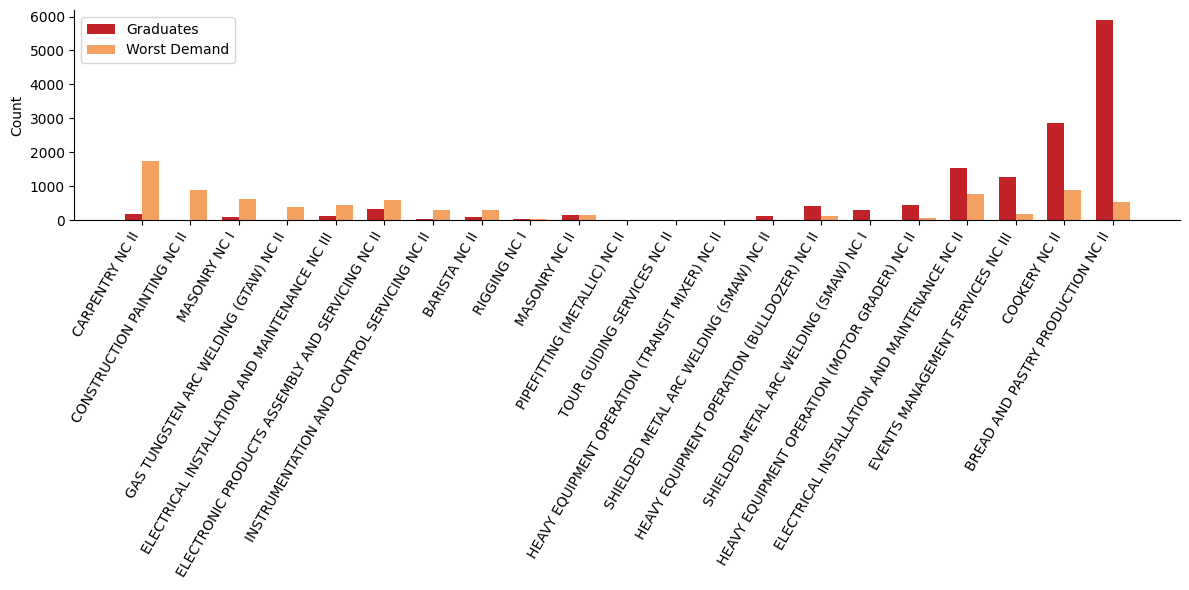

In [12]:
import matplotlib.pyplot as plt
import pandas as pd

# Compute supply gap
qualification_df['Supply Gap'] = qualification_df['Graduates'] - qualification_df['Worst Demand']

# Sort by supply gap
sorted_df = qualification_df.sort_values('Supply Gap', ascending=True)

# Select bottom 8, 5 middle, top 8 for smoother continuum
bottom = sorted_df.head(8)
middle = sorted_df.iloc[len(sorted_df)//2 - 2 : len(sorted_df)//2 + 3]
top = sorted_df.tail(8)

# Combine and reset index
plot_df = pd.concat([bottom, middle, top]).reset_index()

# --- Plot ---
x = range(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# Graduates (left bar)
ax.bar([i - width/2 for i in x], plot_df['Graduates'], width, label='Graduates', color='#C22328')

# Base Demand (right bar)
ax.bar([i + width/2 for i in x], plot_df['Worst Demand'], width, label='Worst Demand', color='#f3a161')

# Formatting
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Qualification'], rotation=60, ha='right')
ax.legend()

# Hide spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add visual cue line for middle (approx. balance)
#ax.axvline(len(bottom) - 0.5, color='gray', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


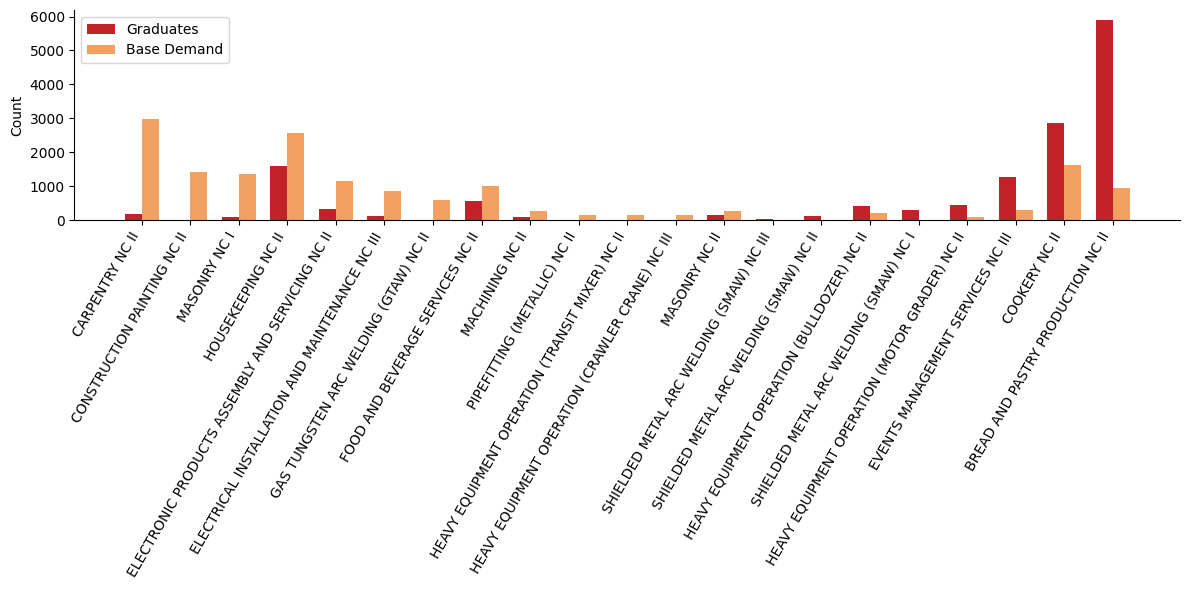

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Compute supply gap
qualification_df['Supply Gap'] = qualification_df['Graduates'] - qualification_df['Base Demand']

# Sort by supply gap
sorted_df = qualification_df.sort_values('Supply Gap', ascending=True)

# Select bottom 8, 5 middle, top 8 for smoother continuum
bottom = sorted_df.head(8)
middle = sorted_df.iloc[len(sorted_df)//2 - 2 : len(sorted_df)//2 + 3]
top = sorted_df.tail(8)

# Combine and reset index
plot_df = pd.concat([bottom, middle, top]).reset_index()

# --- Plot ---
x = range(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# Graduates (left bar)
ax.bar([i - width/2 for i in x], plot_df['Graduates'], width, label='Graduates', color='#C22328')

# Base Demand (right bar)
ax.bar([i + width/2 for i in x], plot_df['Base Demand'], width, label='Base Demand', color='#f3a161')

# Formatting
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Qualification'], rotation=60, ha='right')
ax.legend()

# Hide spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add visual cue line for middle (approx. balance)
#ax.axvline(len(bottom) - 0.5, color='gray', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


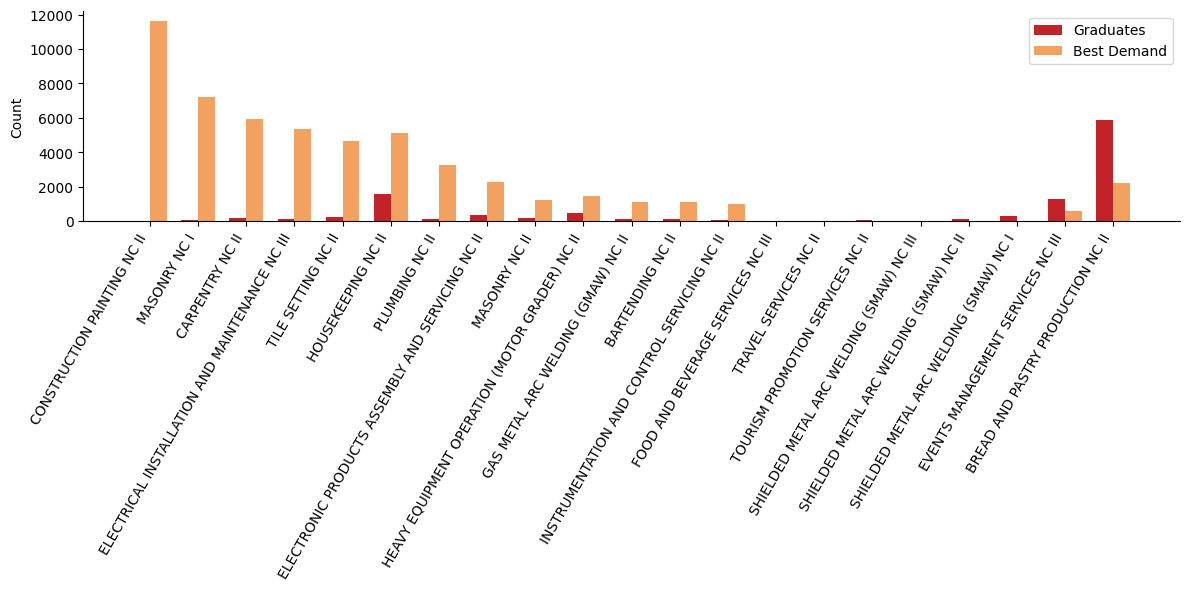

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Compute supply gap
qualification_df['Supply Gap'] = qualification_df['Graduates'] - qualification_df['Best Demand']

# Sort by supply gap
sorted_df = qualification_df.sort_values('Supply Gap', ascending=True)

# Select bottom 8, 5 middle, top 8 for smoother continuum
bottom = sorted_df.head(8)
middle = sorted_df.iloc[len(sorted_df)//2 - 2 : len(sorted_df)//2 + 3]
top = sorted_df.tail(8)

# Combine and reset index
plot_df = pd.concat([bottom, middle, top]).reset_index()

# --- Plot ---
x = range(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

# Graduates (left bar)
ax.bar([i - width/2 for i in x], plot_df['Graduates'], width, label='Graduates', color='#C22328')

# Base Demand (right bar)
ax.bar([i + width/2 for i in x], plot_df['Best Demand'], width, label='Best Demand', color='#f3a161')

# Formatting
ax.set_ylabel('Count')
ax.set_xticks(x)
ax.set_xticklabels(plot_df['Qualification'], rotation=60, ha='right')
ax.legend()

# Hide spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Add visual cue line for middle (approx. balance)
#ax.axvline(len(bottom) - 0.5, color='gray', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()
